# Eksperymenty hiperparametrów

Notebook sprawdza, jak wybrane hiperparametry wpływają na accuracy modeli LSTM i Transformer dla rozpoznawania krótkich komend głosowych. Struktura jest podobna do `02_baseline_models.ipynb`: najpierw definicja konfiguracji, potem przygotowanie danych, uruchomienie treningów i analiza wyników. Notebook nie uruchamia eksperymentów automatycznie po otwarciu.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts import (
    DataFixedParams,
    DataGridParams,
    Experiment,
    FeatureFixedParams,
    FitFixedParams,
    FitGridParams,
    LABEL_ORDER,
    ModelGridParams,
    experiment_grid_dataframe,
    prepare_experiment_datasets,
    train_experiment,
)

LABEL_ORDER

('yes',
 'no',
 'up',
 'down',
 'left',
 'right',
 'on',
 'off',
 'stop',
 'go',
 'unknown',
 'silence')

## Konfiguracja bazowa

Najważniejsze ustawienia są wypisane wprost w tej komórce. `BASE_HYPERPARAMETERS` to punkt odniesienia, a sekcja `STUDIES` niżej mówi, które wartości będą zmieniane w kolejnych eksperymentach.

In [2]:
EPOCHS = 10
OUTPUT_DIR = "reports/03_hyperparameter_experiments"
ARCHITECTURES = ["lstm", "transformer"]

DATA_GRID_CONFIG = {
    "train_fraction": 0.1,
    "validation_fraction": 0.1,
    "test_fraction": 0.1,
    "unknown_fraction": 0.01,
    "silence_samples": 50,
    "sampling_strategy": "natural",
    "seed": 42,
}

FEATURE_CONFIG = {
    "n_mels": 64,
    "n_fft": 512,
    "hop_length": 160,
    "normalize": True,
}

FIT_FIXED_CONFIG = {
    "device": "cuda",
    "use_tqdm": True,
    "progress_backend": "terminal",
    "verbose": True,
    "early_stopping": False,
}

BASE_HYPERPARAMETERS = {
    "dropout": 0.2,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 128,
    "capacity": 128,
}

base_data_fixed = DataFixedParams(
    cache_dir=".cache/hyperparameter_audio",
    output_dir=OUTPUT_DIR,
)
base_data_grid = DataGridParams(**DATA_GRID_CONFIG)
base_feature_fixed = FeatureFixedParams(**FEATURE_CONFIG)
base_fit_fixed = FitFixedParams(**FIT_FIXED_CONFIG)

pd.DataFrame(
    [
        {"group": "data", **DATA_GRID_CONFIG},
        {"group": "features", **FEATURE_CONFIG},
        {"group": "fit", **FIT_FIXED_CONFIG, "epochs": EPOCHS},
        {"group": "baseline", **BASE_HYPERPARAMETERS},
    ]
)

,group,train_fraction,validation_fraction,test_fraction,unknown_fraction,silence_samples,sampling_strategy,seed,n_mels,n_fft,...,use_tqdm,progress_backend,verbose,early_stopping,epochs,dropout,learning_rate,weight_decay,batch_size,capacity
0,data,0.1,0.1,0.1,0.01,50.0,natural,42.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,512.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,terminal,True,False,10.0,NaN,NaN,NaN,NaN,NaN
3,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.2,0.001,0.0001,128.0,128.0


## Konfiguracje eksperymentów

Poniższa tabela jest głównym miejscem edycji. Każde badanie zmienia jeden parametr względem `BASE_HYPERPARAMETERS`; pozostałe ustawienia zostają stałe.

In [3]:
STUDIES = [
    {"study": "architecture", "parameter": "model_type", "values": ["lstm", "transformer"]},
    {"study": "dropout", "parameter": "dropout", "values": [0.0, 0.2, 0.4]},
    {"study": "learning_rate", "parameter": "learning_rate", "values": [1e-4, 5e-4, 1e-3]},
    {"study": "weight_decay", "parameter": "weight_decay", "values": [0.0, 1e-4, 1e-3]},
    {"study": "batch_size", "parameter": "batch_size", "values": [64, 128, 256]},
    {"study": "capacity", "parameter": "model_capacity", "values": [64, 128, 256]},
]

pd.DataFrame(STUDIES)

,study,parameter,values
0,architecture,model_type,"[lstm, transformer]"
1,dropout,dropout,"[0.0, 0.2, 0.4]"
2,learning_rate,learning_rate,"[0.0001, 0.0005, 0.001]"
3,weight_decay,weight_decay,"[0.0, 0.0001, 0.001]"
4,batch_size,batch_size,"[64, 128, 256]"
5,capacity,model_capacity,"[64, 128, 256]"


In [4]:
def slug_value(value) -> str:
    return str(value).replace("-", "m").replace(".", "p")


def overrides_for(parameter: str, value) -> dict:
    if parameter == "model_type":
        return {}
    if parameter == "model_capacity":
        return {"capacity": value}
    return {parameter: value}


def make_experiment(name: str, architecture: str, overrides: dict | None = None) -> Experiment:
    hp = {**BASE_HYPERPARAMETERS, **(overrides or {})}

    return Experiment(
        name=name,
        data_fixed=base_data_fixed,
        data_grid=base_data_grid,
        feature_fixed=base_feature_fixed,
        model_grid=ModelGridParams(
            model_type=architecture,
            dropout=hp["dropout"],
            lstm_hidden_size=hp["capacity"],
            lstm_layers=2,
            lstm_bidirectional=True,
            transformer_d_model=hp["capacity"],
            transformer_heads=4,
            transformer_layers=2,
            transformer_ff_dim=hp["capacity"] * 2,
        ),
        fit_fixed=base_fit_fixed,
        fit_grid=FitGridParams(
            epochs=EPOCHS,
            batch_size=hp["batch_size"],
            learning_rate=hp["learning_rate"],
            weight_decay=hp["weight_decay"],
        ),
    )


experiments = {}
plan_rows = []

for spec in STUDIES:
    parameter = spec["parameter"]
    for value in spec["values"]:
        architectures = [value] if parameter == "model_type" else ARCHITECTURES
        for architecture in architectures:
            overrides = overrides_for(parameter, value)
            hp = {**BASE_HYPERPARAMETERS, **overrides}
            experiment_name = f"03_{spec['study']}_{architecture}_{parameter}_{slug_value(value)}"

            experiments[experiment_name] = make_experiment(experiment_name, architecture, overrides)
            plan_rows.append(
                {
                    "study": spec["study"],
                    "parameter": parameter,
                    "value": value,
                    "architecture": architecture,
                    **hp,
                    "experiment_name": experiment_name,
                    "runs": 1,
                }
            )

experiment_plan = pd.DataFrame(plan_rows)
plan_columns = [
    "study",
    "parameter",
    "value",
    "architecture",
    "dropout",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "capacity",
    "experiment_name",
    "runs",
]

experiment_plan[plan_columns]

,study,parameter,value,architecture,dropout,learning_rate,weight_decay,batch_size,capacity,experiment_name,runs
0,architecture,model_type,lstm,lstm,0.2,0.0010,0.0001,128,128,03_architecture_lstm_model_type_lstm,1
1,architecture,model_type,transformer,transformer,0.2,0.0010,0.0001,128,128,03_architecture_transformer_model_type_transfo...,1
2,dropout,dropout,0.0,lstm,0.0,0.0010,0.0001,128,128,03_dropout_lstm_dropout_0p0,1
3,dropout,dropout,0.0,transformer,0.0,0.0010,0.0001,128,128,03_dropout_transformer_dropout_0p0,1
4,dropout,dropout,0.2,lstm,0.2,0.0010,0.0001,128,128,03_dropout_lstm_dropout_0p2,1
5,dropout,dropout,0.2,transformer,0.2,0.0010,0.0001,128,128,03_dropout_transformer_dropout_0p2,1
6,dropout,dropout,0.4,lstm,0.4,0.0010,0.0001,128,128,03_dropout_lstm_dropout_0p4,1
7,dropout,dropout,0.4,transformer,0.4,0.0010,0.0001,128,128,03_dropout_transformer_dropout_0p4,1
8,learning_rate,learning_rate,0.0001,lstm,0.2,0.0001,0.0001,128,128,03_learning_rate_lstm_learning_rate_0p0001,1
9,learning_rate,learning_rate,0.0001,transformer,0.2,0.0001,0.0001,128,128,03_learning_rate_transformer_learning_rate_0p0001,1


In [5]:
experiment_plan.groupby("study", as_index=False)["runs"].sum()

,study,runs
0,architecture,2
1,batch_size,6
2,capacity,6
3,dropout,6
4,learning_rate,6
5,weight_decay,6


## Wybór konfiguracji

Domyślnie zaznaczone są wszystkie badania. Jeśli chcesz uruchomić tylko część, usuń wybrane nazwy z `selected_studies` przed wykonaniem komórek treningowych.

In [6]:
selected_studies = [
    "architecture",
    "dropout",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "capacity",
]

selected_plan = experiment_plan[experiment_plan["study"].isin(selected_studies)].reset_index(drop=True)
selected_plan[plan_columns]

,study,parameter,value,architecture,dropout,learning_rate,weight_decay,batch_size,capacity,experiment_name,runs
0,architecture,model_type,lstm,lstm,0.2,0.0010,0.0001,128,128,03_architecture_lstm_model_type_lstm,1
1,architecture,model_type,transformer,transformer,0.2,0.0010,0.0001,128,128,03_architecture_transformer_model_type_transfo...,1
2,dropout,dropout,0.0,lstm,0.0,0.0010,0.0001,128,128,03_dropout_lstm_dropout_0p0,1
3,dropout,dropout,0.0,transformer,0.0,0.0010,0.0001,128,128,03_dropout_transformer_dropout_0p0,1
4,dropout,dropout,0.2,lstm,0.2,0.0010,0.0001,128,128,03_dropout_lstm_dropout_0p2,1
5,dropout,dropout,0.2,transformer,0.2,0.0010,0.0001,128,128,03_dropout_transformer_dropout_0p2,1
6,dropout,dropout,0.4,lstm,0.4,0.0010,0.0001,128,128,03_dropout_lstm_dropout_0p4,1
7,dropout,dropout,0.4,transformer,0.4,0.0010,0.0001,128,128,03_dropout_transformer_dropout_0p4,1
8,learning_rate,learning_rate,0.0001,lstm,0.2,0.0001,0.0001,128,128,03_learning_rate_lstm_learning_rate_0p0001,1
9,learning_rate,learning_rate,0.0001,transformer,0.2,0.0001,0.0001,128,128,03_learning_rate_transformer_learning_rate_0p0001,1


In [7]:
# Pełna konfiguracja pierwszego zaplanowanego eksperymentu.
example_experiment = experiments[selected_plan.loc[0, "experiment_name"]]
experiment_grid_dataframe(example_experiment)

,experiment,data.train_fraction,data.validation_fraction,data.test_fraction,data.unknown_fraction,data.silence_samples,data.sampling_strategy,data.seed,model.model_type,model.dropout,...,model.lstm_layers,model.lstm_bidirectional,model.transformer_d_model,model.transformer_heads,model.transformer_layers,model.transformer_ff_dim,fit.epochs,fit.batch_size,fit.learning_rate,fit.weight_decay
0,03_architecture_lstm_model_type_lstm,0.1,0.1,0.1,0.01,50,natural,42,lstm,0.2,...,2,True,128,4,2,256,10,128,0.001,0.0001


## Przygotowanie danych

Dane są przygotowywane raz, bo wszystkie eksperymenty korzystają z identycznego podziału danych. Potem ten sam obiekt `prepared_data` jest przekazywany do kolejnych treningów.

In [8]:
data_cache_experiment = make_experiment(
    "03_shared_hyperparameter_data_cache",
    architecture="lstm",
)

prepared_data = prepare_experiment_datasets(data_cache_experiment)


Building dataset
  -> samples | train=2190 | validation=309 | test=310
     class        train  validation  test
     down          185          27    26
     go            187          26    26
     left          184          25    27
     no            186          27    26
     off           184          26    27
     on            187          26    25
     right         186          26    26
     silence         5           5     5
     stop          189          25    25
     unknown       326          43    43
     up            185          26    28
     yes           186          27    26


## Uruchomienie eksperymentów

Ta komórka uruchamia wszystkie konfiguracje z `selected_plan`. Każdy trening ma ustawione `epochs=20`.

In [9]:
all_results = []

for index, row in selected_plan.iterrows():
    experiment_name = row["experiment_name"]
    experiment = experiments[experiment_name]
    print(f"[{index + 1}/{len(selected_plan)}] {experiment_name}")

    summary = train_experiment(experiment, prepared_data).copy()
    summary.insert(0, "study", row["study"])
    summary.insert(1, "parameter", row["parameter"])
    summary.insert(2, "value", row["value"])
    summary.insert(3, "architecture", row["architecture"])
    summary.insert(4, "experiment_name", experiment_name)
    all_results.append(summary)

all_results = pd.concat(all_results, ignore_index=True)
output_path = Path(OUTPUT_DIR) / "hyperparameter_experiment_summary.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
all_results.to_csv(output_path, index=False)
all_results.sort_values("test_accuracy", ascending=False)

[1/32] 03_architecture_lstm_model_type_lstm
Starting experiment: 03_architecture_lstm_model_type_lstm

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.1
  - validation_fraction: 0.1
  - test_fraction: 0.1
  - unknown_fraction: 0.01
  - silence_samples: 50
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.2
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 10/10 [00:49<00:00,  4.95s/it, loss=0.6913, lr=0.001, val_acc=0.7540, val_loss=0.7732]


Training finished in 49.93 seconds



Experiment finished | total runs = 1
[2/32] 03_architecture_transformer_model_type_transformer
Starting experiment: 03_architecture_transformer_model_type_transformer

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.1
  - validation_fraction: 0.1
  - test_fraction: 0.1
  - unknown_fraction: 0.01
  - silence_samples: 50
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.2
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 10/10 [00:33<00:00,  3.37s/it, loss=0.6673, lr=0.001, val_acc=0.7346, val_loss=0.8371]


Training finished in 34.08 seconds



Experiment finished | total runs = 1
[3/32] 03_dropout_lstm_dropout_0p0
Starting experiment: 03_dropout_lstm_dropout_0p0

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.1
  - validation_fraction: 0.1
  - test_fraction: 0.1
  - unknown_fraction: 0.01
  - silence_samples: 50
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.0
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


...

Training: 100%|██████████| 10/10 [00:24<00:00,  2.46s/it, loss=0.5061, lr=0.001, val_acc=0.7961, val_loss=0.6612]


Training finished in 24.88 seconds



Experiment finished | total runs = 1
[32/32] 03_capacity_transformer_model_capacity_256
Starting experiment: 03_capacity_transformer_model_capacity_256

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.1
  - validation_fraction: 0.1
  - test_fraction: 0.1
  - unknown_fraction: 0.01
  - silence_samples: 50
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.2
  - lstm_hidden_size: 256
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 256
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 512
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 10/10 [00:23<00:00,  2.31s/it, loss=0.3540, lr=0.001, val_acc=0.7799, val_loss=0.7531]


Training finished in 23.36 seconds



Experiment finished | total runs = 1


,study,parameter,value,architecture,experiment_name,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
30,capacity,model_capacity,256,lstm,03_capacity_lstm_model_capacity_256,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.506140,0.826027,0.661196,0.796117,0.729239,0.774194
18,weight_decay,weight_decay,0.001,lstm,03_weight_decay_lstm_weight_decay_0p001,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.658625,0.790411,0.702526,0.763754,0.740979,0.764516
20,batch_size,batch_size,64,lstm,03_batch_size_lstm_batch_size_64,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,8,10,False,0.662741,0.788128,0.663422,0.789644,0.733005,0.761290
0,architecture,model_type,lstm,lstm,03_architecture_lstm_model_type_lstm,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
22,batch_size,batch_size,128,lstm,03_batch_size_lstm_batch_size_128,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
4,dropout,dropout,0.2,lstm,03_dropout_lstm_dropout_0p2,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
12,learning_rate,learning_rate,0.001,lstm,03_learning_rate_lstm_learning_rate_0p001,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
28,capacity,model_capacity,128,lstm,03_capacity_lstm_model_capacity_128,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
16,weight_decay,weight_decay,0.0001,lstm,03_weight_decay_lstm_weight_decay_0p0001,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
21,batch_size,batch_size,64,transformer,03_batch_size_transformer_batch_size_64,trfm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.418354,0.866667,0.779363,0.754045,0.855971,0.735484


## Wczytanie zapisanych wyników

Jeśli notebook został przerwany po treningu, ta komórka pozwala wrócić do analizy bez ponownego uruchamiania modeli.

In [10]:
summary_path = Path(OUTPUT_DIR) / "hyperparameter_experiment_summary.csv"

if summary_path.exists():
    all_results = pd.read_csv(summary_path)

all_results.sort_values("test_accuracy", ascending=False).head(10)

,study,parameter,value,architecture,experiment_name,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
30,capacity,model_capacity,256,lstm,03_capacity_lstm_model_capacity_256,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.506140,0.826027,0.661196,0.796117,0.729239,0.774194
18,weight_decay,weight_decay,0.001,lstm,03_weight_decay_lstm_weight_decay_0p001,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.658625,0.790411,0.702526,0.763754,0.740979,0.764516
20,batch_size,batch_size,64,lstm,03_batch_size_lstm_batch_size_64,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,8,10,False,0.662741,0.788128,0.663422,0.789644,0.733005,0.761290
0,architecture,model_type,lstm,lstm,03_architecture_lstm_model_type_lstm,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
22,batch_size,batch_size,128,lstm,03_batch_size_lstm_batch_size_128,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
4,dropout,dropout,0.2,lstm,03_dropout_lstm_dropout_0p2,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
12,learning_rate,learning_rate,0.001,lstm,03_learning_rate_lstm_learning_rate_0p001,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
28,capacity,model_capacity,128,lstm,03_capacity_lstm_model_capacity_128,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
16,weight_decay,weight_decay,0.0001,lstm,03_weight_decay_lstm_weight_decay_0p0001,lstm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.691332,0.770776,0.773232,0.754045,0.738812,0.754839
21,batch_size,batch_size,64,transformer,03_batch_size_transformer_batch_size_64,trfm_train0_1_val0_1_test0_1_lr0_001_seed42,10,10,False,0.418354,0.866667,0.779363,0.754045,0.855971,0.735484


## Analiza wyników

Poniższe komórki porównują najlepsze konfiguracje oraz pokazują wpływ pojedynczych hiperparametrów osobno dla LSTM i Transformera.

In [11]:
best_by_study = (
    all_results.sort_values("test_accuracy", ascending=False)
    .groupby(["study", "architecture"], as_index=False)
    .first()
)

best_by_study[[
    "study",
    "architecture",
    "parameter",
    "value",
    "test_accuracy",
    "validation_accuracy",
    "best_epoch",
    "epochs_trained",
    "stopped_early",
]]

,study,architecture,parameter,value,test_accuracy,validation_accuracy,best_epoch,epochs_trained,stopped_early
0,architecture,lstm,model_type,lstm,0.754839,0.754045,10,10,False
1,architecture,transformer,model_type,transformer,0.725806,0.734628,10,10,False
2,batch_size,lstm,batch_size,64,0.761290,0.789644,8,10,False
3,batch_size,transformer,batch_size,64,0.735484,0.754045,10,10,False
4,capacity,lstm,model_capacity,256,0.774194,0.796117,10,10,False
5,capacity,transformer,model_capacity,256,0.725806,0.783172,9,10,False
6,dropout,lstm,dropout,0.2,0.754839,0.754045,10,10,False
7,dropout,transformer,dropout,0.2,0.725806,0.734628,10,10,False
8,learning_rate,lstm,learning_rate,0.001,0.754839,0.754045,10,10,False
9,learning_rate,transformer,learning_rate,0.001,0.725806,0.734628,10,10,False


In [12]:
accuracy_table = all_results.pivot_table(
    index=["study", "parameter", "value"],
    columns="architecture",
    values="test_accuracy",
    aggfunc="max",
).reset_index()

accuracy_table

architecture,study,parameter,value,lstm,transformer
0,architecture,model_type,lstm,0.754839,NaN
1,architecture,model_type,transformer,NaN,0.725806
2,batch_size,batch_size,128,0.754839,0.725806
3,batch_size,batch_size,256,0.719355,0.700000
4,batch_size,batch_size,64,0.761290,0.735484
5,capacity,model_capacity,128,0.754839,0.725806
6,capacity,model_capacity,256,0.774194,0.725806
7,capacity,model_capacity,64,0.635484,0.635484
8,dropout,dropout,0.0,0.735484,0.712903
9,dropout,dropout,0.2,0.754839,0.725806


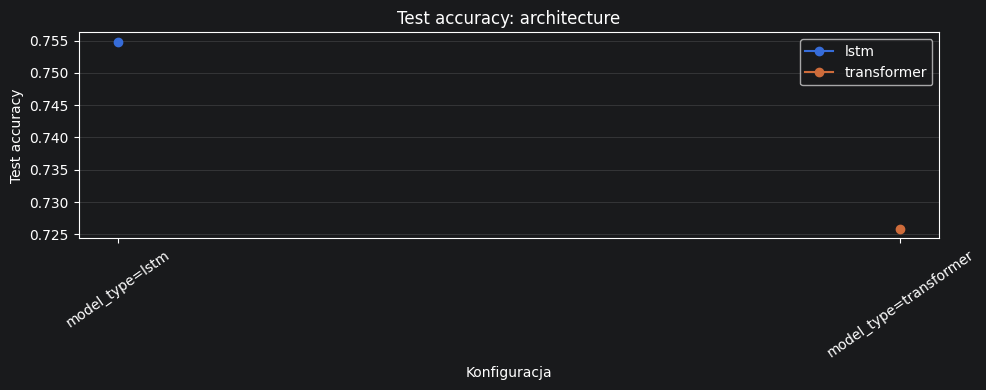

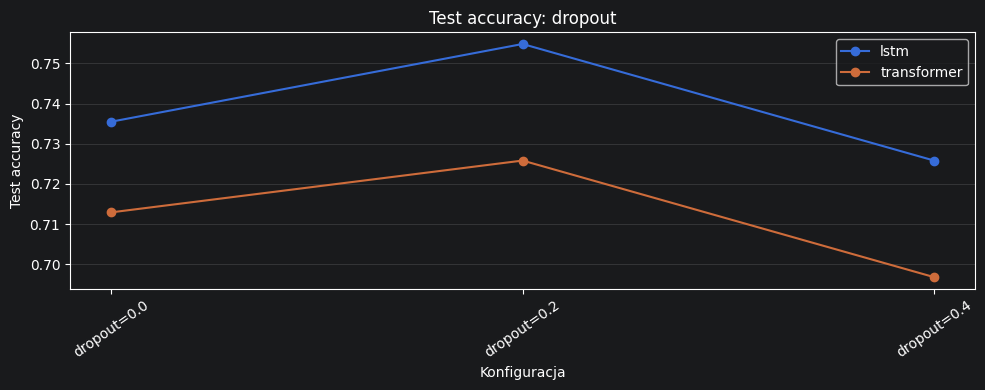

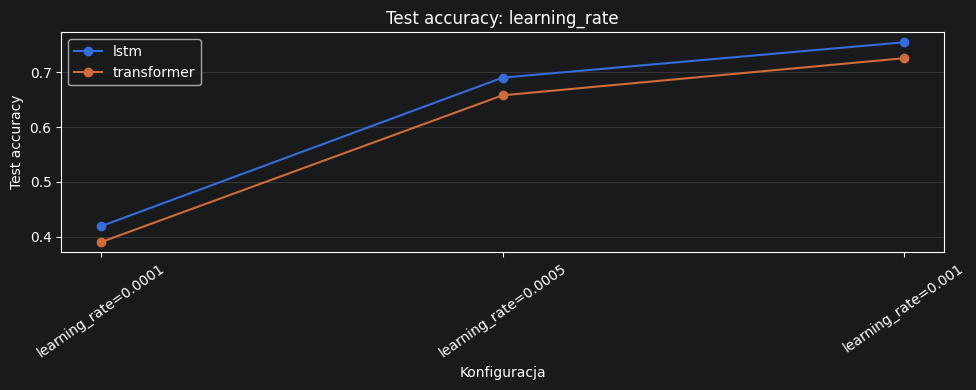

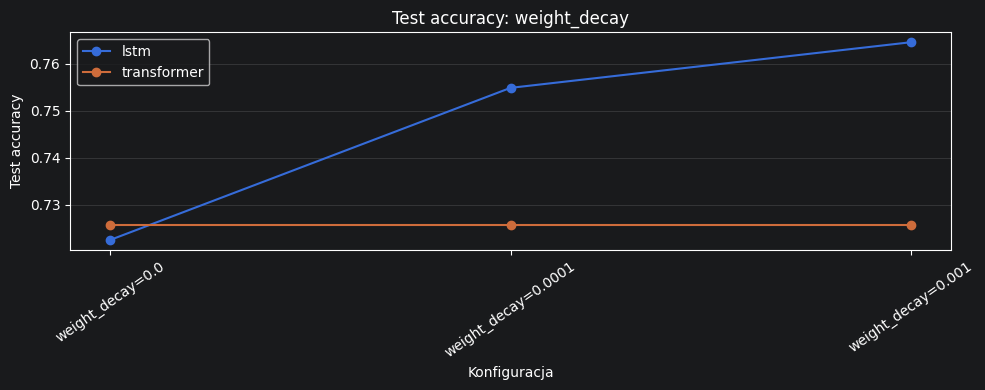

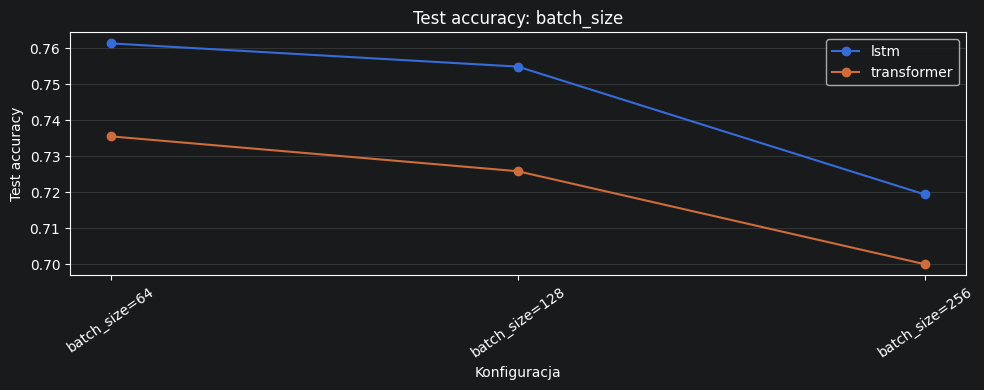

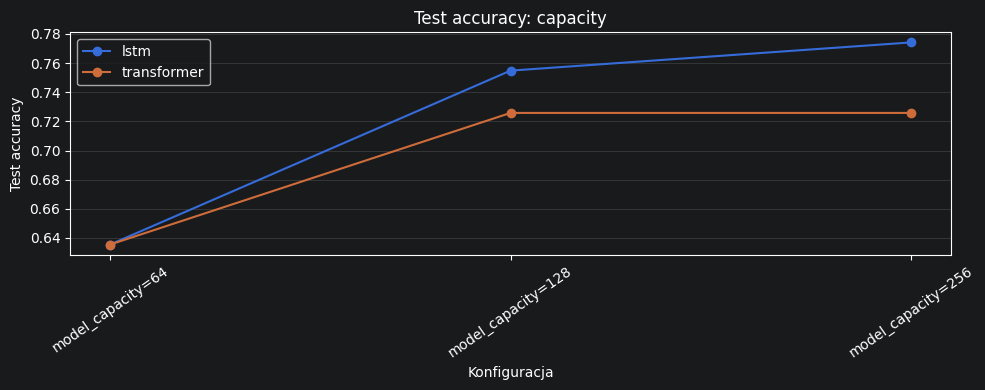

In [13]:
plot_data = all_results.copy()
plot_data["label"] = plot_data["parameter"] + "=" + plot_data["value"].astype(str)

for study, study_data in plot_data.groupby("study", sort=False):
    fig, axis = plt.subplots(figsize=(10, 4))
    for architecture, architecture_data in study_data.groupby("architecture", sort=False):
        axis.plot(
            architecture_data["label"],
            architecture_data["test_accuracy"],
            marker="o",
            label=architecture,
        )

    axis.set_title(f"Test accuracy: {study}")
    axis.set_xlabel("Konfiguracja")
    axis.set_ylabel("Test accuracy")
    axis.tick_params(axis="x", rotation=35)
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

## Kandydaci do finalnego porównania

Po uruchomieniu eksperymentów ta komórka wybiera najlepsze wyniki per architektura. To dobry punkt startowy do kolejnego, małego eksperymentu łączącego najlepsze wartości.

In [14]:
final_candidates = (
    all_results.sort_values("test_accuracy", ascending=False)
    .groupby("architecture", as_index=False)
    .head(5)
    [[
        "architecture",
        "study",
        "parameter",
        "value",
        "test_accuracy",
        "validation_accuracy",
        "best_epoch",
        "experiment_name",
    ]]
)

final_candidates

,architecture,study,parameter,value,test_accuracy,validation_accuracy,best_epoch,experiment_name
30,lstm,capacity,model_capacity,256,0.774194,0.796117,10,03_capacity_lstm_model_capacity_256
18,lstm,weight_decay,weight_decay,0.001,0.764516,0.763754,10,03_weight_decay_lstm_weight_decay_0p001
20,lstm,batch_size,batch_size,64,0.761290,0.789644,8,03_batch_size_lstm_batch_size_64
0,lstm,architecture,model_type,lstm,0.754839,0.754045,10,03_architecture_lstm_model_type_lstm
22,lstm,batch_size,batch_size,128,0.754839,0.754045,10,03_batch_size_lstm_batch_size_128
21,transformer,batch_size,batch_size,64,0.735484,0.754045,10,03_batch_size_transformer_batch_size_64
15,transformer,weight_decay,weight_decay,0.0,0.725806,0.734628,10,03_weight_decay_transformer_weight_decay_0p0
5,transformer,dropout,dropout,0.2,0.725806,0.734628,10,03_dropout_transformer_dropout_0p2
13,transformer,learning_rate,learning_rate,0.001,0.725806,0.734628,10,03_learning_rate_transformer_learning_rate_0p001
1,transformer,architecture,model_type,transformer,0.725806,0.734628,10,03_architecture_transformer_model_type_transfo...
